In [2]:
!pip install pandas scikit-learn nltk spacy PyPDF2 sentence-transformers joblib streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 97.6 MB/s eta 0:00:00


In [3]:
# Download spaCy model
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 82.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [5]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import re
import spacy
import joblib
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [6]:
# LOAD SPACY MODEL
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

In [8]:
# LOAD DATASETS
resumes = pd.read_csv("ResumeData.csv")
jobs = pd.read_csv("Jobb.csv")

print("Resume Dataset Shape:", resumes.shape)
print("Job Dataset Shape:", jobs.shape)

Resume Dataset Shape: (2502, 165)
Job Dataset Shape: (1068, 7)


In [9]:
# REMOVE MISSING VALUES

resumes.dropna(subset=["Resume_str", "Category"], inplace=True)
jobs.dropna(inplace=True)

print("After Removing Nulls:", resumes.shape)

After Removing Nulls: (2466, 165)


In [10]:
# REMOVE DUPLICATES

resumes.drop_duplicates(subset=["Resume_str"], inplace=True)

print("After Removing Duplicates:", resumes.shape)

After Removing Duplicates: (2464, 165)


In [11]:
# REMOVE SHORT / BROKEN RESUMES

resumes["word_count"] = resumes["Resume_str"].apply(
    lambda x: len(str(x).split())
)

In [12]:
# Keep resumes with more than 50 words
resumes = resumes[resumes["word_count"] > 50]

print("After Removing Short Resumes:", resumes.shape)

After Removing Short Resumes: (2456, 166)


In [13]:
# TEXT CLEANING FUNCTION
def clean_text(text):

    if not isinstance(text, str):
        return ""

    # Lowercase
    text = text.lower()

    # Remove newline
    text = re.sub(r"\n", " ", text)

    # Remove symbols/numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # spaCy processing
    doc = nlp(text)

    cleaned_words = []

    for token in doc:

        # Remove stopwords + punctuation
        if not token.is_stop and not token.is_punct:

            # Lemmatization
            cleaned_words.append(token.lemma_)

    return " ".join(cleaned_words)

In [14]:
# CLEAN RESUME TEXT

resumes["clean"] = resumes["Resume_str"].apply(clean_text)

# Remove empty rows
resumes = resumes[resumes["clean"].str.strip() != ""]

print("After Cleaning:", resumes.shape)

After Cleaning: (2456, 167)


In [15]:
# SAVE CLEANED DATASET
# =========================================

resumes.to_csv("Resume_clean.csv", index=False)

print("Cleaned Resume Dataset Saved")

Cleaned Resume Dataset Saved


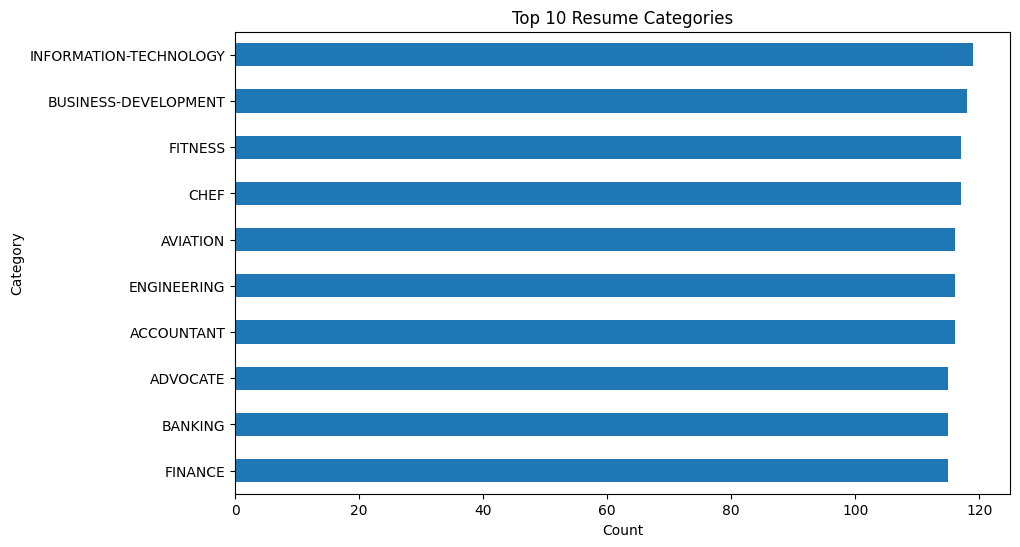

In [16]:
# DATA VISUALIZATION
# CATEGORY DISTRIBUTION

counts = resumes["Category"].value_counts().head(10)

plt.figure(figsize=(10,6))
counts.plot(kind="barh")

plt.title("Top 10 Resume Categories")
plt.xlabel("Count")
plt.gca().invert_yaxis()

plt.show()

In [20]:
# TF-IDF VECTORIZATION
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1,2),
    min_df=2
)

X = tfidf.fit_transform(resumes["clean"])

y = resumes["Category"]

print("TF-IDF Shape:", X.shape)


TF-IDF Shape: (2456, 10000)


In [24]:
# FOR BETTER ACCURACY
category_counts = resumes["Category"].value_counts()

valid_categories = category_counts[category_counts >= 5].index

resumes = resumes[resumes["Category"].isin(valid_categories)]

print("Remaining Categories:")
print(resumes["Category"].value_counts())

Remaining Categories:
Category
INFORMATION-TECHNOLOGY    119
BUSINESS-DEVELOPMENT      118
FITNESS                   117
CHEF                      117
ENGINEERING               116
ACCOUNTANT                116
AVIATION                  116
ADVOCATE                  115
BANKING                   115
CONSULTANT                115
FINANCE                   115
SALES                     115
HEALTHCARE                113
PUBLIC-RELATIONS          110
HR                        109
CONSTRUCTION              108
DESIGNER                  106
ARTS                      103
TEACHER                   102
APPAREL                    96
DIGITAL-MEDIA              95
AGRICULTURE                63
AUTOMOBILE                 35
BPO                        21
Name: count, dtype: int64


In [25]:
# TRAIN TEST SPLIT
X = tfidf.fit_transform(resumes["clean"])
y = resumes["Category"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train/Test Split Complete")

Train/Test Split Complete


In [26]:
# TRAIN MODEL (LinearSVC)
model = LinearSVC()

model.fit(X_train, y_train)

print("Model Training Complete")

Model Training Complete


In [27]:
# PREDICTIONS
y_pred = model.predict(X_test)

In [30]:
# EVALUATION
accuracy = accuracy_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred, average="weighted")

print("\n===== LinearSVC Evaluation =====")

print("Accuracy:", accuracy)

print("F1 Score:", f1)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


===== LinearSVC Evaluation =====
Accuracy: 0.745417515274949
F1 Score: 0.7321157583326159

Classification Report:

                        precision    recall  f1-score   support

            ACCOUNTANT       0.71      0.87      0.78        23
              ADVOCATE       0.60      0.65      0.62        23
           AGRICULTURE       1.00      0.46      0.63        13
               APPAREL       0.69      0.58      0.63        19
                  ARTS       0.82      0.43      0.56        21
            AUTOMOBILE       0.67      0.29      0.40         7
              AVIATION       0.77      0.74      0.76        23
               BANKING       0.75      0.78      0.77        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.79      0.96      0.87        24
                  CHEF       0.89      0.70      0.78        23
          CONSTRUCTION       0.86      0.86      0.86        22
            CONSULTANT       0.50      0.35      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [41]:
# LOGISTIC REGRESSION EVALUATION
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))


===== Logistic Regression =====
Accuracy: 0.6802443991853361
F1 Score: 0.6586896985486996


<Figure size 1200x1200 with 0 Axes>

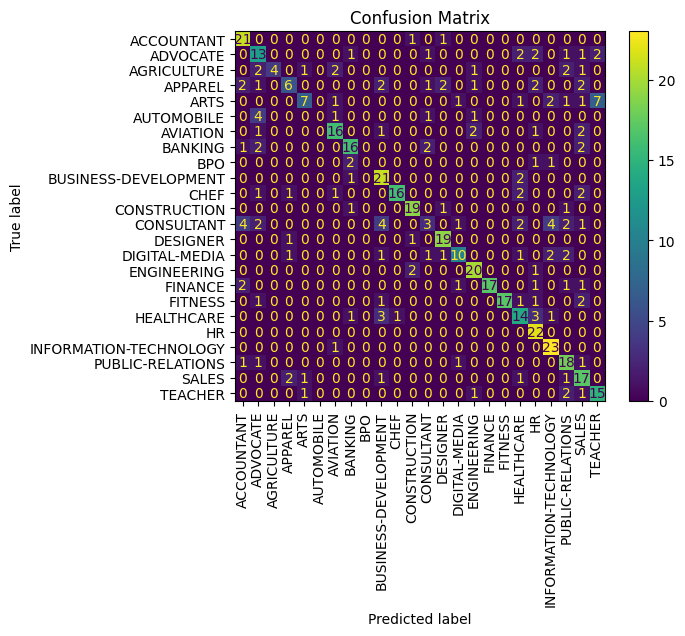

In [42]:
# CONFUSION MATRIX
plt.figure(figsize=(12,12))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(xticks_rotation=90)

plt.title("Confusion Matrix")

plt.show()

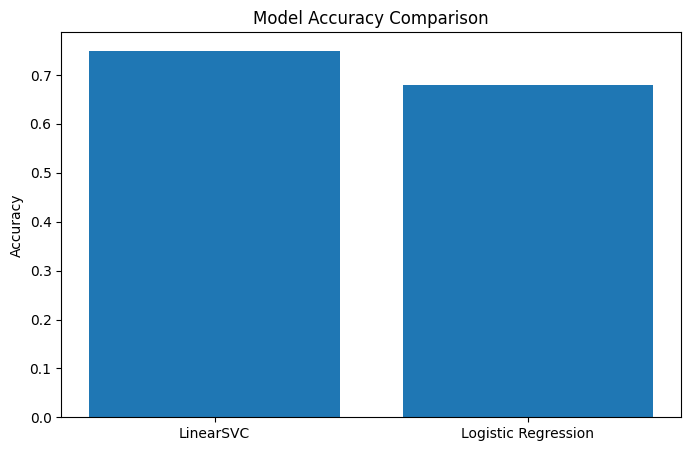

In [43]:
models = ["LinearSVC","Logistic Regression"]
accuracy = [0.75, 0.68]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [31]:
# PROCESS JOB DATASET
jobs["text"] = (

    jobs["Title"].astype(str) + " " +

    jobs["Skills"].astype(str) + " " +

    jobs["Responsibilities"].astype(str) + " " +

    jobs["Keywords"].astype(str)
)

jobs["clean"] = jobs["text"].apply(clean_text)

jobs = jobs[jobs["clean"].str.strip() != ""]

print("Cleaned Job Dataset Shape:", jobs.shape)

Cleaned Job Dataset Shape: (1067, 9)


In [33]:
# SAVE CLEANED JOB DATASET
jobs.to_csv("Job_clean.csv", index=False)

print("Cleaned Job Dataset Saved")

Cleaned Job Dataset Saved


In [34]:
# SAVE MODEL + TFIDF

joblib.dump(model, "model.pkl")

joblib.dump(tfidf, "tfidf.pkl")

print("Model + TFIDF Saved Successfully")

Model + TFIDF Saved Successfully


In [35]:
# EMBEDDINGS FOR JOB MATCHING
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# Example Resume
sample_resume = resumes["clean"].iloc[0]

# Encode resume
resume_embedding = embedder.encode([sample_resume])

# Encode jobs
job_embeddings = embedder.encode(jobs["clean"].tolist())

# Similarity
similarities = cosine_similarity(
    resume_embedding,
    job_embeddings
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [36]:
# Top 5 jobs
top_indices = similarities[0].argsort()[-5:][::-1]

print("\n===== Top Recommended Jobs =====")

for idx in top_indices:

    print(
        jobs.iloc[idx]["Title"],
        "→ Similarity:",
        round(similarities[0][idx], 2)
    )


===== Top Recommended Jobs =====
Operations Manager → Similarity: 0.49
Operations Manager → Similarity: 0.48
Digital Marketing Specialist → Similarity: 0.47
Operations Manager → Similarity: 0.46
Operations Manager → Similarity: 0.46


In [37]:
# FINAL MESSAGE
print("\nTraining + Evaluation Complete")


Training + Evaluation Complete
